# Spectral GC: Comparing Spectral Estimation Methods

This notebook compares bivariate spectral Granger Causality computed from the
same underlying signal using all four spectral backends available in `pygc`:

| `spectral_method` | Estimator | Notes |
|---|---|---|
| `'fourier'` | Trial-averaged FFT periodogram | Needs multiple trials; full frequency resolution |
| `'welch'` | Welch overlapping-window average | Works on single long trial; fixed `nperseg` |
| `'morlet'` | Morlet wavelet CSD, time-averaged | Fixed frequency grid; good time–frequency localisation |
| `'multitaper'` | Multitaper (DPSS) CSD via MNE | Reduced spectral leakage; `bandwidth` controls smoothing |

We use the **Dhamala bivariate AR model** (Y drives X at ~40 Hz) as the ground truth.
The expected result is a clear GC(Y→X) peak near 40 Hz and near-zero GC(X→Y).

## 1. Imports and configuration

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sp_signal

from pygc.ar_model import ar_model_dhamala
from pygc.granger import granger_causality
from pygc.spectral_analysis import multitaper_freq

plt.rcParams.update({"figure.dpi": 100, "font.size": 12})

FS = 200  # sampling rate (Hz)
N = 4000  # samples per trial
TRIALS = 500  # independent trials
C = 0.25  # coupling Y → X
SEED = 42

# Morlet frequency grid
MORLET_FREQS = np.linspace(5, 95, 100)  # Hz
N_CYCLES = 7.0

# Multitaper bandwidth
BANDWIDTH = 4.0  # Hz  (controls spectral smoothing; default ≈ 8 * Fs/N)

## 2. Generate AR model data

Data shape: (2, 500, 4000)  (channels, trials, samples)


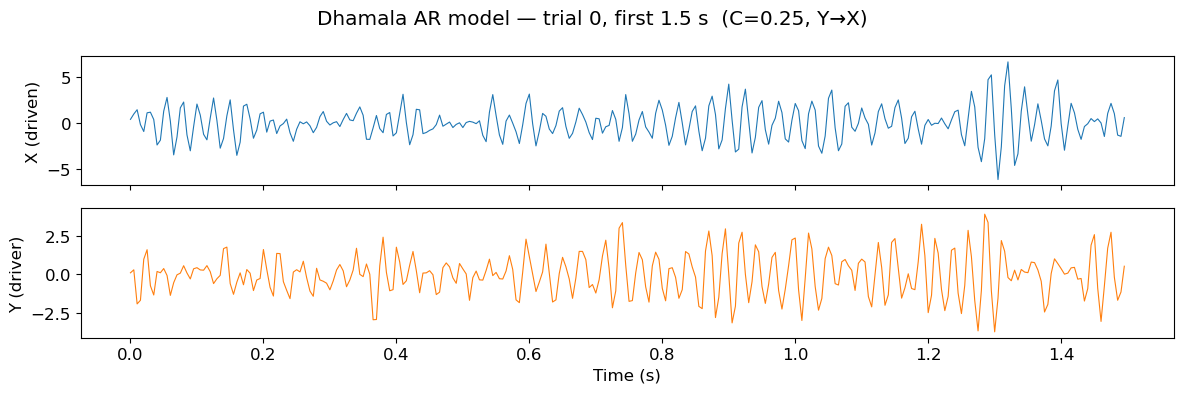

In [2]:
np.random.seed(SEED)

cov = np.array([[0.5, 0.0], [0.0, 0.5]])
Z = ar_model_dhamala(N=N, Trials=TRIALS, Fs=FS, C=C, t_start=0, t_stop=None, cov=cov)
# Z shape: (2, TRIALS, N)
#   Z[0] = X  (driven by Y)
#   Z[1] = Y  (driver)

print(f"Data shape: {Z.shape}  (channels, trials, samples)")

# ── Quick look at the signals ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
t = np.arange(N) / FS
axes[0].plot(t[:300], Z[0, 0, :300], lw=0.8, color="C0")
axes[0].set_ylabel("X (driven)")
axes[1].plot(t[:300], Z[1, 0, :300], lw=0.8, color="C1")
axes[1].set_ylabel("Y (driver)")
axes[1].set_xlabel("Time (s)")
fig.suptitle(f"Dhamala AR model — trial 0, first 1.5 s  (C={C}, Y→X)")
plt.tight_layout()

## 3. Compute spectral GC with each method

All three calls use the same underlying Wilson factorization (NumPy backend).
Only the cross-spectral matrix estimator differs.


### 3a. Fourier (trial-averaged periodogram)

`spectral_method='fourier'` computes the FFT of each trial separately and averages
the resulting cross-spectra. It requires multiple trials so the CSD matrix is full-rank.
Frequency resolution = Fs/N.


In [3]:
# (Trials, 2, N)
data = Z.transpose(1, 0, 2)

Ix2y_f, Iy2x_f, _, f_fourier = granger_causality(
    data, FS, spectral_method="fourier", Niterations=200, verbose=False
)

from pygc.spectral_analysis.fourier import compute_freq

print(
    f"Fourier  — freq bins: {len(f_fourier)}  ({f_fourier[0]:.2f}–{f_fourier[-1]:.1f} Hz)"
)
print(
    f"           GC(Y→X) mean: {Iy2x_f.mean():.4f}   GC(X→Y) mean: {Ix2y_f.mean():.4f}"
)

Fourier  — freq bins: 2001  (0.05–100.0 Hz)
           GC(Y→X) mean: 0.1439   GC(X→Y) mean: 0.0010


### 3b. Welch (overlapping-window average)

`spectral_method='welch'` uses `scipy.signal.csd` with a Hann window (default `nperseg=256`),
averaging over both segments within each trial and across trials.
Frequency resolution = Fs/nperseg ≈ 0.78 Hz.


In [4]:
Ix2y_w, Iy2x_w, _, f_welch = granger_causality(
    data, FS, spectral_method="welch", Niterations=200, verbose=False
)

print(f"Welch    — freq bins: {len(f_welch)}  ({f_welch[0]:.2f}–{f_welch[-1]:.1f} Hz)")
print(
    f"           GC(Y→X) mean: {Iy2x_w.mean():.4f}   GC(X→Y) mean: {Ix2y_w.mean():.4f}"
)

Welch    — freq bins: 129  (0.00–100.0 Hz)
           GC(Y→X) mean: 0.1416   GC(X→Y) mean: 0.0000


/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


### 3c. Morlet wavelet (time-averaged CSD)

`spectral_method='morlet'` computes the Morlet wavelet transform via MNE and averages
the instantaneous cross-spectra over time for each trial.
The frequency grid is user-defined (`spectral_params={'freqs': ...}`).


In [5]:
Ix2y_m, Iy2x_m, _, MORLET_FREQS = granger_causality(
    data,
    FS,
    spectral_method="morlet",
    Niterations=200,
    verbose=False,
    spectral_params={"freqs": MORLET_FREQS, "n_cycles": N_CYCLES},
)

print(
    f"Morlet   — freq bins: {len(MORLET_FREQS)}  ({MORLET_FREQS[0]:.1f}–{MORLET_FREQS[-1]:.1f} Hz)"
)
print(
    f"           GC(Y→X) mean: {Iy2x_m.mean():.4f}   GC(X→Y) mean: {Ix2y_m.mean():.4f}"
)

Morlet   — freq bins: 100  (5.0–95.0 Hz)
           GC(Y→X) mean: 0.1517   GC(X→Y) mean: 0.0062


### 3d. Multitaper (DPSS)

`spectral_method='multitaper'` uses `mne.time_frequency.csd_array_multitaper` to estimate
the cross-spectral matrix with DPSS (Slepian) tapers. Unlike Welch, it uses the full signal
length for a single tapered estimate, giving reduced spectral leakage. The `bandwidth`
parameter (Hz) sets the half-bandwidth of the DPSS tapers and controls the smoothing:
smaller values → sharper peaks but fewer tapers; larger values → more smoothing but more stable estimates.

In [6]:
Ix2y_mt, Iy2x_mt, _, f_mt = granger_causality(
    data, FS, spectral_method="multitaper", Niterations=200, verbose=False,
    spectral_params={"bandwidth": BANDWIDTH},
)

print(f"Multitaper — freq bins: {len(f_mt)}  ({f_mt[0]:.2f}–{f_mt[-1]:.1f} Hz)")
print(
    f"             GC(Y→X) mean: {Iy2x_mt.mean():.4f}   GC(X→Y) mean: {Ix2y_mt.mean():.4f}"
)

/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Multitaper — freq bins: 2000  (0.05–100.0 Hz)
             GC(Y→X) mean: 0.1408   GC(X→Y) mean: 0.0001


/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


## 4. Comparison

All three methods should recover the Y→X coupling peak near 40 Hz.
The main differences are spectral resolution and smoothness.


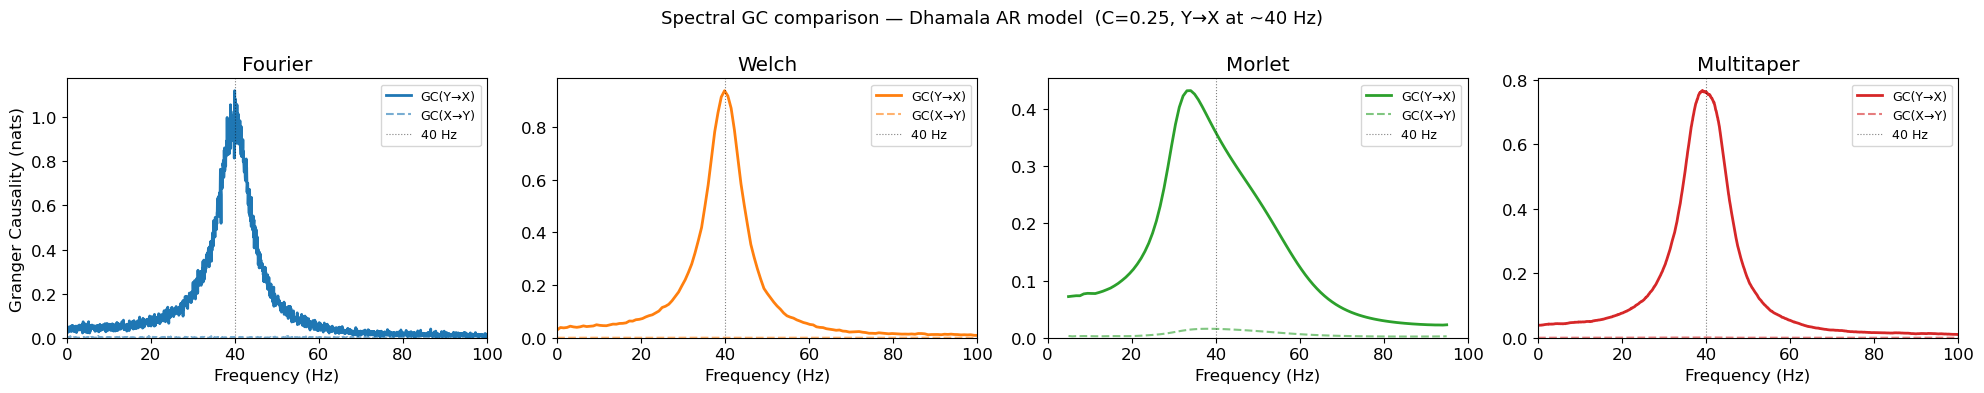

In [7]:
FMAX = 100  # plot up to 100 Hz

methods = [
    ("Fourier",     f_fourier,    Ix2y_f,  Iy2x_f,  "C0"),
    ("Welch",       f_welch,      Ix2y_w,  Iy2x_w,  "C1"),
    ("Morlet",      MORLET_FREQS, Ix2y_m,  Iy2x_m,  "C2"),
    ("Multitaper",  f_mt,         Ix2y_mt, Iy2x_mt, "C3"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=False)

for ax, (name, f, x2y, y2x, color) in zip(axes, methods):
    mask = f <= FMAX
    ax.plot(f[mask], y2x[mask], color=color, lw=2, label="GC(Y→X)")
    ax.plot(
        f[mask], x2y[mask], color=color, lw=1.5,
        label="GC(X→Y)", linestyle="--", alpha=0.6,
    )
    ax.axvline(40, color="k", lw=0.8, linestyle=":", alpha=0.5, label="40 Hz")
    ax.set_title(name)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_xlim([0, FMAX])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Granger Causality (nats)")
fig.suptitle(
    f"Spectral GC comparison — Dhamala AR model  (C={C}, Y→X at ~40 Hz)", fontsize=13
)
plt.tight_layout()

### Overlay: GC(Y→X) across all three methods

Overlaying the dominant direction makes it easy to compare peak position and sharpness.


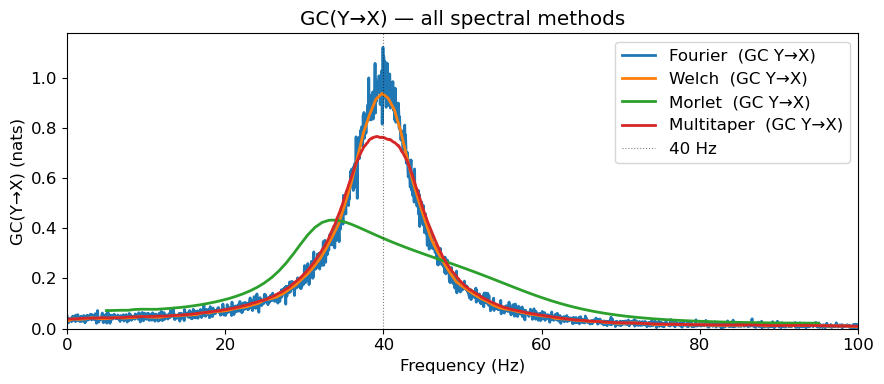

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

for name, f, x2y, y2x, color in methods:
    mask = f <= FMAX
    ax.plot(f[mask], y2x[mask], color=color, lw=2, label=f"{name}  (GC Y→X)")

ax.axvline(40, color="k", lw=0.8, linestyle=":", alpha=0.5, label="40 Hz")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("GC(Y→X) (nats)")
ax.set_xlim([0, FMAX])
ax.set_ylim(bottom=0)
ax.legend()
ax.set_title("GC(Y→X) — all spectral methods")
plt.tight_layout()

## 5. Effect of Welch window size

Larger `nperseg` → finer frequency resolution but fewer averages per trial
(higher variance). Smaller `nperseg` → smoother but lower resolution.


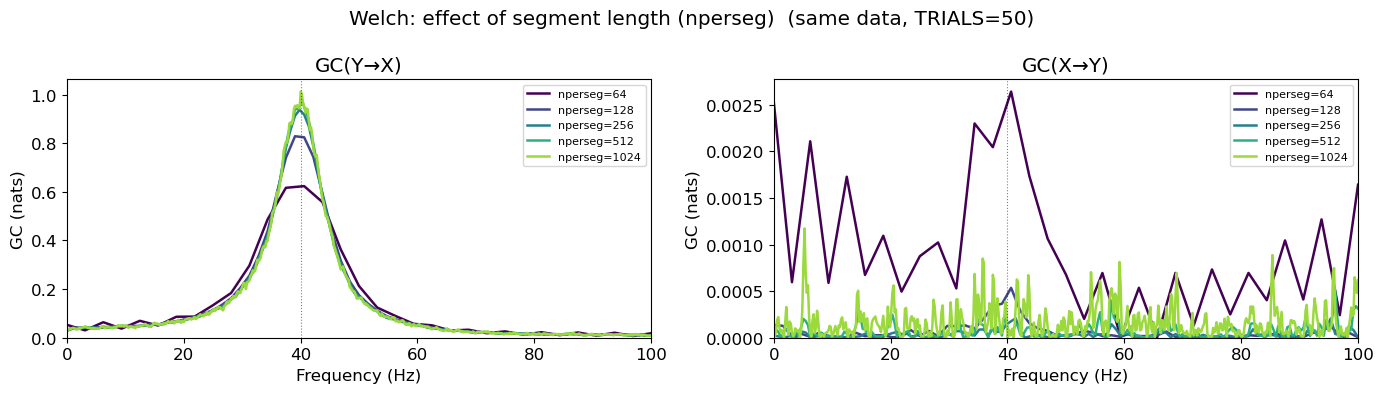

In [9]:
npersegs = [64, 128, 256, 512, 1024]
colors = plt.cm.viridis(np.linspace(0, 0.85, len(npersegs)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for nperseg, col in zip(npersegs, colors):
    Ix2y_wn, Iy2x_wn, _,  f_wn= granger_causality(
        data,
        FS,
        spectral_method="welch",
        Niterations=200,
        verbose=False,
        spectral_params={"nperseg": nperseg, "window": "hann"},
    )
    mask = f_wn <= FMAX
    axes[0].plot(
        f_wn[mask], Iy2x_wn[mask], color=col, lw=1.8, label=f"nperseg={nperseg}"
    )
    axes[1].plot(
        f_wn[mask], Ix2y_wn[mask], color=col, lw=1.8, label=f"nperseg={nperseg}"
    )

for ax, title in zip(axes, ["GC(Y→X)", "GC(X→Y)"]):
    ax.axvline(40, color="k", lw=0.8, linestyle=":", alpha=0.5)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("GC (nats)")
    ax.set_title(title)
    ax.set_xlim([0, FMAX])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

fig.suptitle("Welch: effect of segment length (nperseg)  (same data, TRIALS=50)")
plt.tight_layout()

## 6. Effect of Morlet wavelet cycles

`n_cycles` controls the time–frequency trade-off: more cycles → sharper frequency
resolution but longer kernel (needs longer signals).


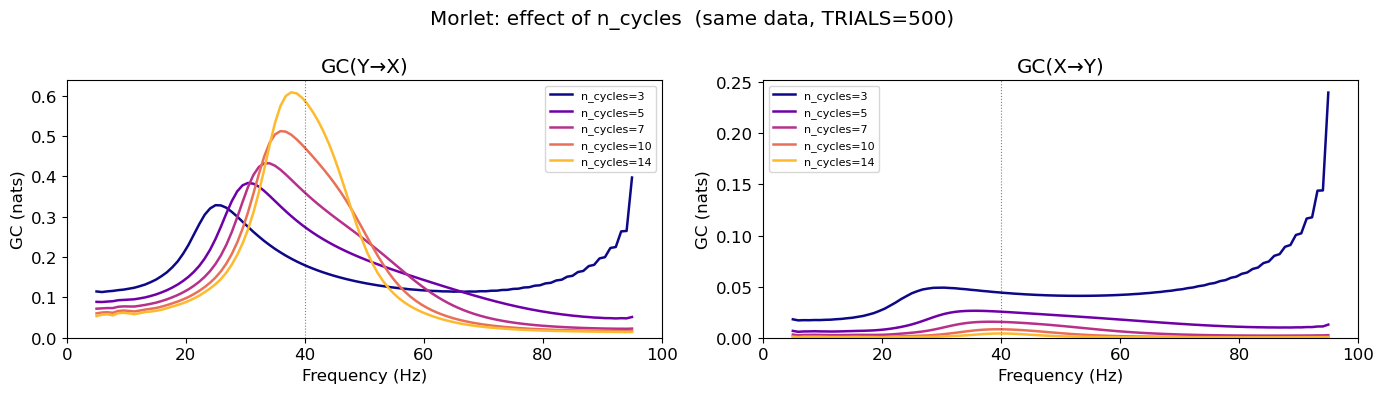

In [10]:
n_cycles_list = [3, 5, 7, 10, 14]
colors_m = plt.cm.plasma(np.linspace(0, 0.85, len(n_cycles_list)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for nc, col in zip(n_cycles_list, colors_m):
    Ix2y_mn, Iy2x_mn, _, MORLET_FREQS = granger_causality(
        data,
        FS,
        spectral_method="morlet",
        Niterations=200,
        verbose=False,
        spectral_params={"freqs": MORLET_FREQS, "n_cycles": nc},
    )
    mask = MORLET_FREQS <= FMAX
    axes[0].plot(
        MORLET_FREQS[mask], Iy2x_mn[mask], color=col, lw=1.8, label=f"n_cycles={nc}"
    )
    axes[1].plot(
        MORLET_FREQS[mask], Ix2y_mn[mask], color=col, lw=1.8, label=f"n_cycles={nc}"
    )

for ax, title in zip(axes, ["GC(Y→X)", "GC(X→Y)"]):
    ax.axvline(40, color="k", lw=0.8, linestyle=":", alpha=0.5)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("GC (nats)")
    ax.set_title(title)
    ax.set_xlim([0, FMAX])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

fig.suptitle(f"Morlet: effect of n_cycles  (same data, TRIALS={TRIALS})")
plt.tight_layout()

## 7. Effect of multitaper bandwidth

`bandwidth` sets the half-bandwidth of the DPSS tapers (Hz). It controls the
number of tapers used: `K ≈ 2 * bandwidth * N / Fs - 1`. A larger bandwidth
averages more tapers → smoother but lower spectral resolution. A smaller bandwidth
preserves peak sharpness but may increase variance.

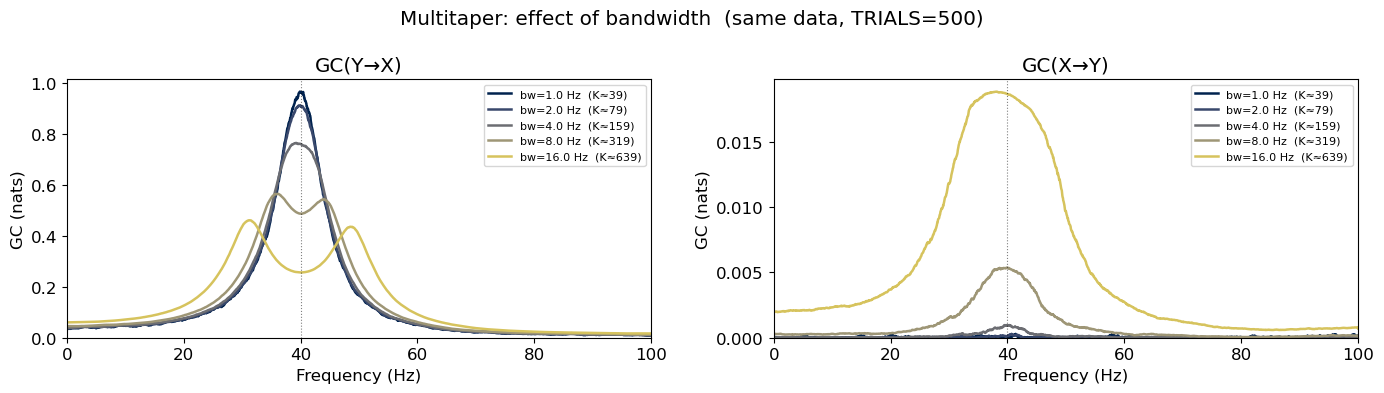

In [11]:
bandwidths = [1.0, 2.0, 4.0, 8.0, 16.0]
colors_mt = plt.cm.cividis(np.linspace(0, 0.85, len(bandwidths)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for bw, col in zip(bandwidths, colors_mt):
    n_tapers = max(1, int(2 * bw * N / FS - 1))
    Ix2y_bw, Iy2x_bw, _, f_bw = granger_causality(
        data, FS, spectral_method="multitaper", Niterations=200, verbose=False,
        spectral_params={"bandwidth": bw},
    )
    mask = f_bw <= FMAX
    axes[0].plot(f_bw[mask], Iy2x_bw[mask], color=col, lw=1.8,
                 label=f"bw={bw} Hz  (K≈{n_tapers})")
    axes[1].plot(f_bw[mask], Ix2y_bw[mask], color=col, lw=1.8,
                 label=f"bw={bw} Hz  (K≈{n_tapers})")

for ax, title in zip(axes, ["GC(Y→X)", "GC(X→Y)"]):
    ax.axvline(40, color="k", lw=0.8, linestyle=":", alpha=0.5)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("GC (nats)")
    ax.set_title(title)
    ax.set_xlim([0, FMAX])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

fig.suptitle(f"Multitaper: effect of bandwidth  (same data, TRIALS={TRIALS})")
plt.tight_layout()